Maks Burchard, 5V3, SLT

**Uitleg van het programma**

Dit is een python-programma die de kortste route in een graph tussen twee nodes berekent.

De gebruiker kan zelf een graph invoeren of de ingebouwde example-graph gebruiken, die uit [de Wikipedia-pagina van het Dijkstra algoritme komt.](https://en.wikipedia.org/wiki/Dijkstra's_algorithm#/media/File:Dijkstra_Animation.gif) 

Als de gebruiker een eigen graph wil invoren, dan moet hij/zij eerst het aantal nodes invoeren. Hiermee berekent het programma eerst het maximale aantal edges dat de graph kan hebben. Daarna vraagt het programma om de weight van elke edge. De gebruiker kan een weight tussen 0 en 99 zetten (een weight van 0 betekent dat de edge niet bestaat). Daarna wordt om de start en end node gevraagt en nadat de gebruiker dat heeft ingevoert, rekent het programma de kortste route tussen die twee nodes. Het programma doet dit door het Dijkstra-algoritme.

De graph is opgeslagen als een array. Het programma gaat voor een bepaalde node (rij en kolom) in alle elementen zoeken waar de onbezochte neighbours liggen. Daarna gaat het programma node by node en berekent het de korstste route voor alle onbezochte neighbours die het vindt. Dan zoekt het programma de node met de korstste route tussen alle onbezochte nodes. Daarna herhaalt het zichzelf voor elke onbezochte node. Het programma eindight als er geen onbezochte nodes meer zijn.

Je hebt de mogelijkheid om te kiezen tussen of het programma opschrijft wat het doet of dat het alleen de resultaten laat zien.

**Ontwerpproces**

Ik heb veel gebruikt van de informatie die ik heb geleert in de masterclass die we hebben gehad op de TU/e, vooral het deel over Dijkstra.De docent had aan mij aanbevolen om een van de algoritmes die we hebben geleert in de masterclass.

Ik koos voor het standaard Dijkstra omdat dit de eerste keer is dat ik in python heb geprogrameerd en dit de meest simpelste vorm van Dijkstra is. 

Voordat ik begon met programeren, heb ik een diagram gemaakt om te begrijpen wat de input, output en de code moesten doen (figuur 1). 

In het begin probeerde ik eerst de inputs die de gebruiker kan geven te programeren en daarna het Dijkstra-algoritme, maar besloot daarna eerst Dijkstra te programeren met een voorbeeldgraph (figuur 2) om zo to controleren of ik het algoritme goed had geprogrameerd.

Om te leren hoe ik een graph kon opslaan in een manier dat het programma informatie eruit kon halen heb ik [dit artikel gebruikt.](https://medium.com/geekculture/how-to-represent-a-graph-data-structure-in-python-9f0df57e33a2)

Nadat ik Dijkstra goed had geprogrameerd heb ik de gebruikerinputs geprogrameerd en dan de optie om de voorbeeldgraph te gebruiken. 

In de algoritme worden alle korste routes op het begin oneindig groot zijn. Omdat python niet met oneindig kan werken, heb ik maar een groot getal genomen (999999999999999999999). Dit is ook waarom ik de maximale weight van een edge op 99 heb gehouden. 

Ik heb veel gebruik gemaakt van de print() functie om te controleren of alles in het programma goed was gegaan.

Figuur 1: Diagram van het programma.

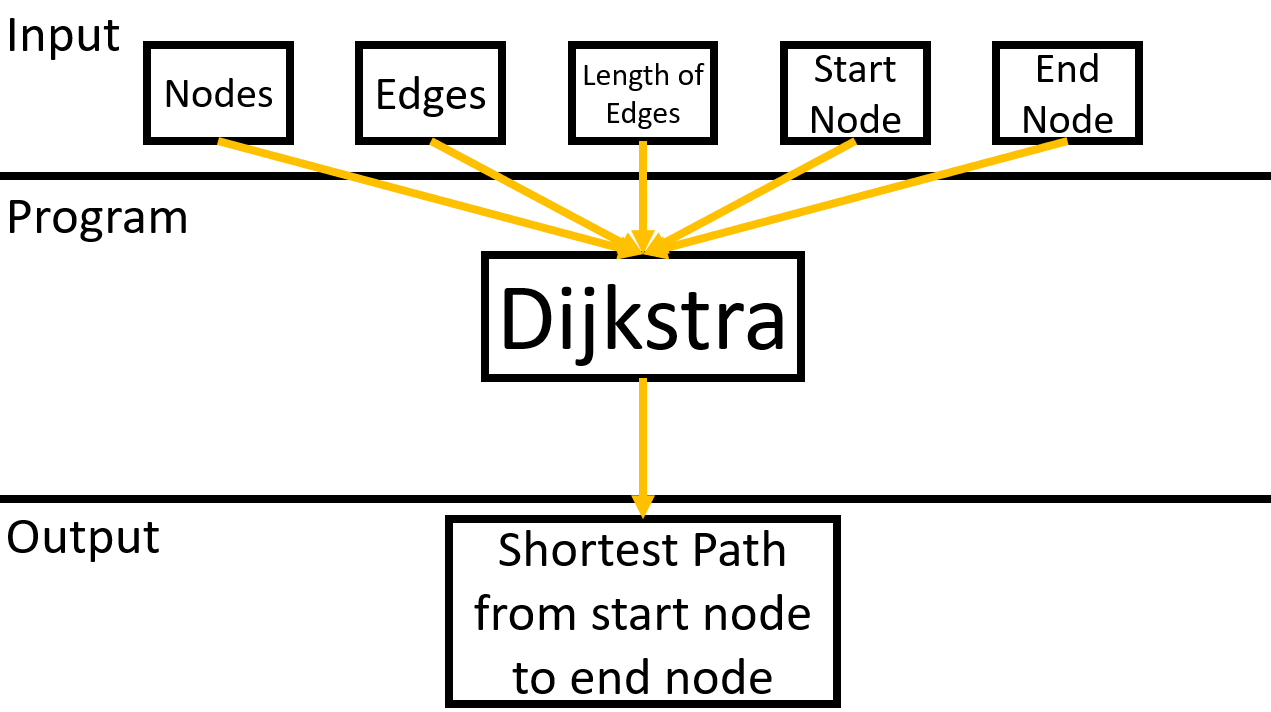

Figuur 2: De graph die ik gebruikte om te kijken of alles correct ging.

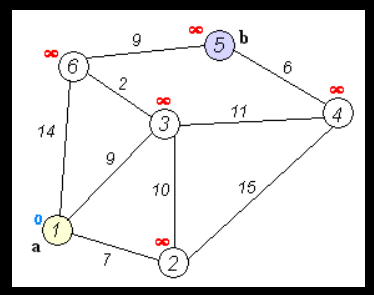

In [1]:
#Maks Burchard, 5V3, 12/05/2023

Version = 5
print("Burchard's Dijkstra\nVersion", Version)

print()
choice = 0
while choice < 1 or choice > 2:
  choice = int(input("Choose user input graph (1) or example graph (2) "))

if choice == 1:
  # User Input
  v = int(input("Enter Number of Vertexes in the graph: "))

  # Give error if nodes out of range
  while (v <= 0):
    v = int(input("Error, amount of Vertexes not possible. \nEnter Number of Vertexes in the graph: "))

  # Calculate maximum number of edges in the graph
  nrOfEdges = (v*(v-1))/2 
  print()
  print('Number of Vertexes = %d; Maximum number of possible edges in the graph = %d' %(v,nrOfEdges))

  # see https://medium.com/geekculture/how-to-represent-a-graph-data-structure-in-python-9f0df57e33a2
  # for Graph Data Structure in Python
  graph = []

  # User inputs the graph
  print()
  print("Enter Graph: by defining all edges")
  h = 0
  for rij in range(v):      # loop for row entries
    a = [] # create a row for a node
    for kolom in range(v):      # loop for column entries
      if rij >= kolom:
        a.append(0) # edge does not exists, add zero
      elif rij < kolom:
        h = h + 1
        print('edge ', h, ': give weigth to edge [', rij, '][', kolom, ']')
        w = int(input())
        while w > 99 or w < 0:
          w = int(input("Weight not in range (0, 99). \nPlease enter weight:"))
        a.append(w) # add edge weight in a row
    graph.append(a) # add all edges of a row 

elif choice == 2:
  # Example Dijkstra 
  # https://en.wikipedia.org/wiki/Dijkstra%27s_algorithm#/media/File:Dijkstra_Animation.gif

  # Number of Vertexes in the graph
  v = 6

  # Calculate maximum number of edges in the graph
  nrOfEdges = (v*(v-1))/2 
  print()
  print('Number of Vertexes = %d; Maximum number of possible edges in the graph = %d' %(v,nrOfEdges))

  graph =[[0, 7, 9, 0, 0, 14], 
          [0, 0, 10, 15, 0, 0],
          [0, 0, 0, 11, 0, 2],
          [0, 0, 0, 0, 6, 0], 
          [0, 0, 0, 0, 0, 9], 
          [0, 0, 0, 0, 0, 0]]

# Print the graph
print()
if choice == 1:
  print("Example Graph:")
elif choice == 2:
  print("Use Defined Graph:")

for rij in range(v):
  for kolom in range(v):
    if (graph[rij][kolom] == 0):
      print("x  ", end = " ")
    elif (graph[rij][kolom] != 0):
      print(graph[rij][kolom], end = "   ")
  print()
print()
print("Note: x means no edge exists")

# Ask user which node to start Dijkstra for
print()
start_node = int(input("Enter Start Node for shortest path calulation: "))
#Give error if node out of range
while start_node > v-1 or start_node < 0:
  start_node = int(input("Error, Node out of range 0..%d \nEnter Start Node for shortest path calulation: " % (v-1)))

end_node   = int(input("Enter End Node for shortest path calulation: "))
#Give error if node out of range
while end_node > v-1 or end_node < 0:
  end_node = int(input("Error, Node out of range 0..%d \nEnter Start Node for shortest path calulation: " % (v-1)))

#Calculate Dijkstra
visited = []
for i in range (v):
  visited.append(0)

shortest_paths = []
for i in range (v):
  shortest_paths.append(999999999999999999999)

print()
print("Calculate Dijktra for path between nodes", start_node, "and", end_node)

detail = 0
while detail > 2 or detail < 1:
  detail = int(input("Do you wish for details to be printed? 1 for yes, 2 for no."))

shortest_paths[start_node] = 0
current_node = start_node

count = 0
keep_running = 1

while keep_running:
  
  # stop if does not work
  count = count+1
  if count == 100000:
    print()
    print("Error: BREAK count = %d" %count)
    break

  if detail == 1:
    print()
    print("-------------------------------------------------")
    print("Find miniumum weight and new_node for current node = ", current_node)
    print("-------------------------------------------------")
    print()
    print("shortest paths from start node = ", start_node)
    #for i in range (v):
    #  print(shortest_paths[i])
    print(shortest_paths)
    print()
    print("shortest path from start node = %d to current node = %d is %d" %(start_node, current_node, shortest_paths[current_node]))

  visited[current_node] = 1
  min_shortest_path = 999999999999999999999
  next_node = current_node

  if detail == 1:
    print()
    print("kolom = %d" %count)
  for kolom in range(v):
    if detail == 1:
      print()
      print("node =",kolom)
      print("shortest_paths =",shortest_paths[kolom])
      print("visited node = %d" %visited[kolom])
    
    # assign shortest paths for all unvisited neighour nodes
    if visited[kolom] == 0: # Consider only unvisited neighours
      weight = graph[current_node][kolom]
      if weight != 0: # The unvisited node is the neighbour
        if detail == 1:
          print("weigth=",weight)
        temp_shortest_path = shortest_paths[current_node] + weight
        if shortest_paths[kolom] == 999999999999999999999:
          shortest_paths[kolom] = temp_shortest_path
        elif shortest_paths[kolom] != 999999999999999999999:
          if temp_shortest_path < shortest_paths[kolom]:
            shortest_paths[kolom] = temp_shortest_path

    # find next unvsitited node with shortest path from start node
    if visited[kolom] == 0: # Consider only unvisited neighours
      if detail == 1:
        print("node = %d shortest_paths = %d" %(kolom, shortest_paths[kolom]))
      if shortest_paths[kolom] < min_shortest_path:
        min_shortest_path = shortest_paths[kolom]
        next_node = kolom
        if detail == 1:
          print("next node = %d min shortest_paths = %d" %(next_node, min_shortest_path))

  if detail == 1:
    print()
    print("rij = %d" %count)
  for rij in range(v):
    if detail == 1:
        print()
        print("node =",rij)
        print("shortest_paths =",shortest_paths[rij])
        print("visited node = %d" %visited[rij])

    # assign shortest paths for all unvisited neighour nodes
    if visited[rij] == 0: # Consider only unvisited neighours
      weight = graph[rij][current_node]
      if weight != 0: # The unvisited node is the neighbour
        if detail == 1:
          print("weigth=",weight)
        temp_shortest_path = shortest_paths[current_node] + weight
        if shortest_paths[rij] == 999999999999999999999:
          shortest_paths[rij] = temp_shortest_path
        elif shortest_paths[rij] != 999999999999999999999:
          if temp_shortest_path < shortest_paths[rij]:
            shortest_paths[rij] = temp_shortest_path

    # find next unsitited node with shortest path from start node
    if visited[rij] == 0: # Consider only unvisited neighours
      if detail == 1:
        print("node = %d shortest_paths = %d" %(kolom, shortest_paths[rij]))
      if shortest_paths[rij] < min_shortest_path:
        min_shortest_path = shortest_paths[rij]
        next_node = rij
        if detail == 1:
          print("next node = %d min shortest_paths = %d" %(next_node, min_shortest_path))

  if detail == 1:
    print()
    print("Done with node = %d, next_node = %d with path = %d" %(current_node, next_node, min_shortest_path))
  current_node = next_node

  # searches if there are unvisited nodes left
  keep_running = 0
  for i in range(v):
    if visited[i] == 0:
      keep_running = 1 # if there are still unvisited nodes keep on running

print()
print("Finished Dijkstra")

print()
print("Shortest path between nodes %d and %d is %d" %(start_node,end_node,shortest_paths[end_node]))

print()
print("All shortest paths from node %d:" %(start_node))
for i in range (v):
  print("  to node %d is %d" %(i,shortest_paths[i]))

print()
print("Done")

Burchard's Dijkstra
Version 5

Choose user input graph (1) or example graph (2) 2

Number of Vertexes = 6; Maximum number of possible edges in the graph = 15

Use Defined Graph:
x   7   9   x   x   14   
x   x   10   15   x   x   
x   x   x   11   x   2   
x   x   x   x   6   x   
x   x   x   x   x   9   
x   x   x   x   x   x   

Note: x means no edge exists

Enter Start Node for shortest path calulation: 0
Enter End Node for shortest path calulation: 4

Calculate Dijktra for path between nodes 0 and 4
Do you wish for details to be printed? 1 for yes, 2 for no.2

Finished Dijkstra

Shortest path between nodes 0 and 4 is 20

All shortest paths from node 0:
  to node 0 is 0
  to node 1 is 7
  to node 2 is 9
  to node 3 is 20
  to node 4 is 20
  to node 5 is 11

Done


**Voorbeeld**

Als je in het programma de volgende inputs geeft:


* Choose user input graph (1) or example graph (2) 2

* Enter Start Node for shortest path calulation: 0

* Enter End Node for shortest path calulation: 4

* Calculate Dijktra for path between nodes: start node = 0 and end node = 4 

* Do you wish for details to be printed? 1 for yes, 2 for no.2

Dan zou je de volgende output moeten krijgen:

Burchard's Dijkstra
Version 3

Choose user input graph (1) or example graph (2) 2

Number of Vertexes = 6; Maximum number of possible edges in the graph = 15

Use Defined Graph:
x   7   9   x   x   14   
x   x   10   15   x   x   
x   x   x   11   x   2   
x   x   x   x   6   x   
x   x   x   x   x   9   
x   x   x   x   x   x   

Note: x means no edge exists

Enter Start Node for shortest path calulation: 0

Enter End Node for shortest path calulation: 4

Calculate Dijktra for path between nodes 0 and 4

Do you wish for details to be printed? 1 for yes, 2 for no.2

Finished Dijkstra

Shortest path between nodes 0 and 4 is 20

All shortest paths from node 0:

  to node 0 is 0

  to node 1 is 7

  to node 2 is 9

  to node 3 is 20

  to node 4 is 20

  to node 5 is 11

Done